In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,  # Регрессионные метрики (из оригинала)
    accuracy_score, precision_score, recall_score, f1_score, # Классификационные метрики
    confusion_matrix, ConfusionMatrixDisplay
)
import os
os.chdir("..")


In [2]:
data_path = Path("/Users/eugene_kuj/PycharmProjects/DS_lab/data/merged_preprocessed.csv")

df = pd.read_csv(data_path)

df.head()

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,...,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago
0,1,2022-03-29 00:00:00+03:00,0,11.6,11.6,27.80,-6.4,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2022-03-29 01:00:00+03:00,0,11.0,11.0,29.92,-6.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2022-03-29 02:00:00+03:00,0,10.3,10.3,32.92,-5.3,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,2022-03-29 03:00:00+03:00,1,9.6,7.8,34.71,-5.3,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2022-03-29 04:00:00+03:00,1,8.5,7.1,36.42,-5.6,0.0,0.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(by=['time', 'region_id']).reset_index(drop=True)

# Изолируем признаки и таргет
X = df.drop(columns=["alarm", "time", "region_id"])
y = df["alarm"]

# Разбиение на train/test с учетом времени (последние 20% данных пойдут на тест)
tss = TimeSeriesSplit(n_splits=5)
train_idx, test_idx = list(tss.split(X))[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [4]:
print("Starting full GridSearchCV for DecisionTreeClassifier...")

model = DecisionTreeClassifier(random_state=42)

# Сетка параметров: 4 * 3 * 3 * 2 = 72 комбинации (отработает очень быстро)
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf': [1, 5, 20],
    'class_weight': [None, 'balanced'] # Учитываем дисбаланс классов
}

# Используем GridSearchCV вместо Randomized (т.к. дерево обучается быстро)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1', # Оптимизируем по F1-score (п. 1.g)
    cv=TimeSeriesSplit(n_splits=3), # Внутренняя кросс-валидация тоже по времени
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"\nBest parameters found: {grid_search.best_params_}")

# --- Предсказания для метрик ---
y_pred = best_model.predict(X_test)

# --- Метрики из "оригинального" файла (Линейной Регрессии) ---
print("\n--- Regression Metrics (from original notebook) ---")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# --- Метрики классификации (для пункта 1.g) ---
print("\n--- Classification Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")

Starting full GridSearchCV for DecisionTreeClassifier...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best parameters found: {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 20, 'min_samples_split': 50}

--- Regression Metrics (from original notebook) ---
MSE: 0.1636
MAE: 0.1636
R2 Score: 0.1939

--- Classification Metrics ---
Accuracy:  0.8364
Precision: 0.6892
Recall:    0.7686
F1 Score:  0.7267



Model saved to decision_tree_best.pkl


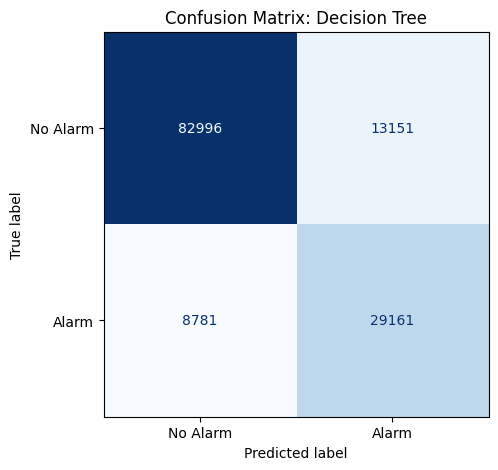

/var/folders/y4/w7fytwyn5_sc1g1w2sxgj15c0000gn/T/ipykernel_73438/4224023499.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_importances, y=top20_features, palette="magma")


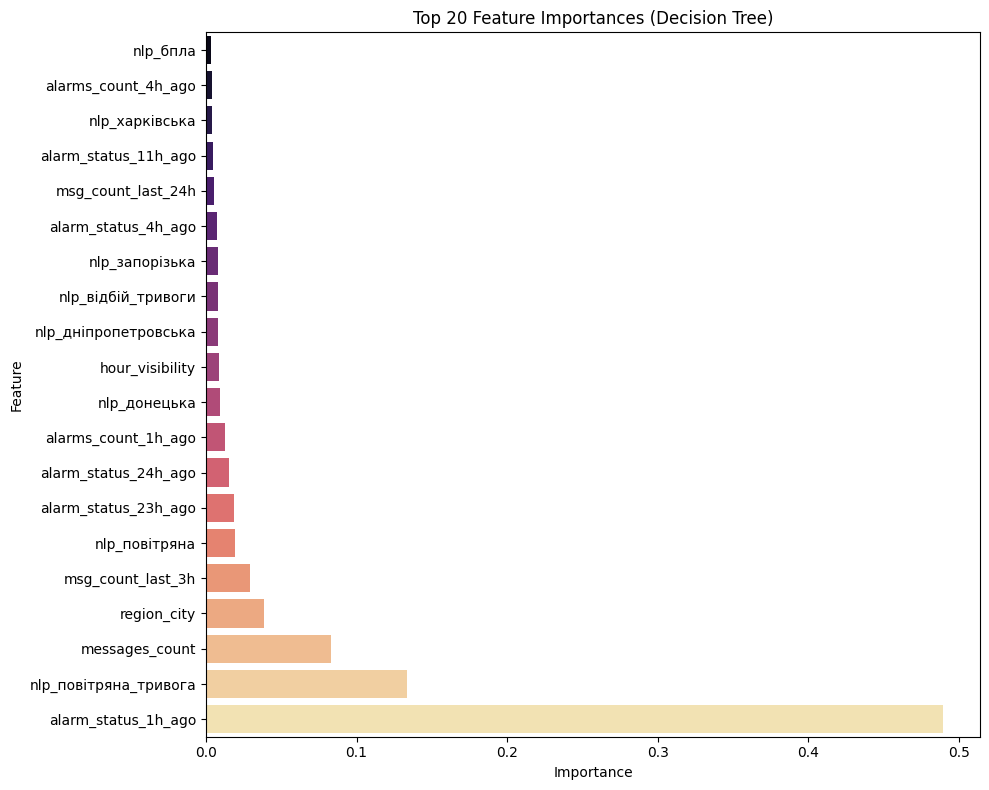

In [6]:
model_filename = 'decision_tree_best.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)
print(f"\nModel saved to {model_filename}")

# --- 1.e Матрица ошибок ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Alarm", "Alarm"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix: Decision Tree")
plt.show()

# --- 1.f Топ-20 самых важных фичей ---
importances = best_model.feature_importances_
feature_names = X.columns

# Сортируем фичи по важности
top20_idx = np.argsort(importances)[-20:]
top20_features = [feature_names[i] for i in top20_idx]
top20_importances = importances[top20_idx]

plt.figure(figsize=(10, 8))
sns.barplot(x=top20_importances, y=top20_features, palette="magma")
plt.title("Top 20 Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

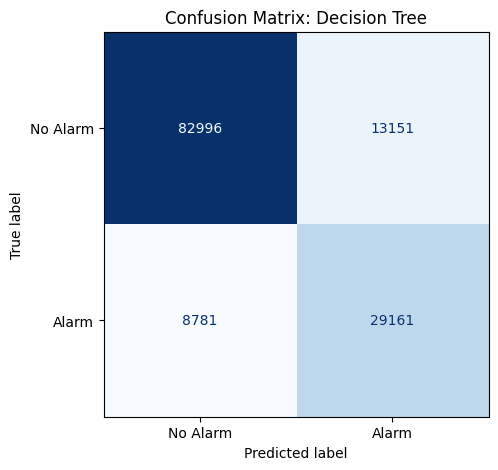

In [7]:
# --- 1.e Матрица ошибок ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Alarm", "Alarm"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix: Decision Tree")
plt.show()